<a href="https://colab.research.google.com/github/muhendis/langchain-langgraph-llm-uygulamalari/blob/master/part1/03_Components.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In this section, we will focus on understanding the core components of the LLM application. Each part plays a specific role in how the system works, from setup to advanced interactions.

You will learn how the following components fit together:

- **Installation** – setting up the environment and dependencies  
- **Helper Functions** – simplifying common and repetitive tasks  
- **Models** – selecting and configuring the language models  
- **Messages** – structuring inputs and outputs for communication  
- **Agents & Tools** – enabling reasoning and external tool usage  
- **Structured Output** – producing reliable, machine-readable results  

By understanding these components individually and how they interact, you will gain a clear mental model of the overall system architecture.


# 1. Installation

In [ ]:
!pip install -U "langchain[google-genai]"
!pip install rich

**To ensure access to the available models and sufficient usage limits, you are kindly requested to have at least a API key.**

# 2. Helper Functions

In [116]:
import os
os.environ["GOOGLE_API_KEY"] = "Your-Key"


In [ ]:
def display_response(response_obj):
    """
    LangChain response objesini analiz eder:
    1. Metadata, Usage, ID gibi teknik verileri JSON Syntax olarak basar.
    2. 'content' kısmını ayırıp Render edilmiş Markdown olarak basar.
    Hepsi tek bir şık panel içinde sunulur.
    """
    from rich.console import Console
    from rich.panel import Panel
    from rich.syntax import Syntax
    from rich.markdown import Markdown
    from rich.console import Group
    from rich.rule import Rule
    import json

    console = Console()

    # 1. Veriyi Pydantic v2 ile al
    data = response_obj.model_dump(exclude_none=True)

    # 2. 'content' kısmını ayır (Çünkü onu özel muamele ile basacağız)
    # Eğer content yoksa boş string döner
    content_text = data.pop("content", "")

    # 3. Geriye kalan teknik verileri (metadata, usage vs.) JSON hazırla
    meta_json = json.dumps(data, indent=4, ensure_ascii=False, default=str)

    # 4. Görsel bileşenleri oluştur
    # A) Teknik Kısım (JSON Syntax)
    json_view = Syntax(meta_json, "json", theme="monokai", word_wrap=True)

    # B) İçerik Kısmı (Rendered Markdown)
    # Eğer içerik boşsa uyarı bas, doluysa render et
    md_view = Markdown(content_text) if content_text else "[italic red]İçerik (Content) Boş[/italic red]"

    # 5. Bileşenleri birleştir (Araya çizgi çekerek)
    render_group = Group(
        json_view,
        Rule(style="blue"),  # Araya şık bir ayraç
        "[bold yellow]▼ RENDER EDİLMİŞ İÇERİK (MARKDOWN) ▼[/bold yellow]",
        Rule(style="blue"),
        md_view
    )

    # 6. Tek panelde bas
    console.print(Panel(
        render_group,
        title=f"[bold green]🤖 AI YANIT ANALİZİ[/bold green]",
        subtitle="[dim]Metadata (JSON) + Content (Markdown)[/dim]",
        border_style="cyan",
        expand=False
    ))


# 3. Models

In [64]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "google_genai:gemini-2.5-flash-lite",
)


In [65]:
response = model.invoke("Merhaba Vodafone Türkiye hakkında bilgi verir misin?")

In [66]:
print(response)

content="Vodafone Türkiye, Türkiye'nin önde gelen mobil iletişim şirketlerinden biridir. İşte Vodafone Türkiye hakkında kapsamlı bir bilgi:\n\n**Genel Bilgiler:**\n\n*   **Kuruluş:** 2006 yılında Telsim'in Vodafone tarafından satın alınmasıyla kurulmuştur.\n*   **Merkez:** İstanbul'da bulunmaktadır.\n*   **Sahibi:** Vodafone Group Plc. (İngiltere merkezli)\n*   **Çalışan Sayısı:** Yaklaşık 9.000 (2023 verisi)\n*   **Müşteri Sayısı:** 24 milyondan fazla (2023 sonu itibarıyla)\n\n**Hizmetler:**\n\n*   **Mobil Hat:** Konuşma, SMS ve mobil internet hizmetleri sunar. Farklı ihtiyaçlara yönelik çeşitli tarife seçenekleri mevcuttur.\n*   **Mobil Geniş Bant (4.5G/5G):** Yüksek hızlı mobil internet erişimi sağlar. 5G altyapısı giderek yaygınlaşmaktadır.\n*   **Ev İnterneti:** Fiber internet (VDSL ve fiber) ve kablosuz internet (4.5G/5G üzerinden) hizmetleri sunar.\n*   **TV:** Vodafone TV platformu üzerinden çeşitli kanallar ve içerikler sunar.\n*   **Kurumsal Çözümler:** İşletmelere yönelik mo

Let's see the output more clearly.

In [67]:
display_response(response)

╭────────────────────────────────────────────── 🤖 AI YANIT ANALİZİ ──────────────────────────────────────────────╮
│ {                                                                                                               │
│     "additional_kwargs": {},                                                                                    │
│     "response_metadata": {                                                                                      │
│         "finish_reason": "STOP",                                                                                │
│         "model_name": "gemma-3-27b-it",                                                                         │
│         "safety_ratings": [],                                                                                   │
│         "model_provider": "google_genai"                                                                        │
│     },                                                                                                          │
│     "type": "ai",                                                                                               │
│     "id": "lc_run--019bf140-adbc-7f03-8009-bb63036dad21-0",                                                     │
│     "tool_calls": [],                                                                                           │
│     "invalid_tool_calls": [],                                                                                   │
│     "usage_metadata": {                                                                                         │
│         "input_tokens": 10,                                                                                     │
│         "output_tokens": 0,                                                                                     │
│         "total_tokens": 10,                                                                                     │
│         "input_token_details": {                                                                                │
│             "cache_read": 0                                                                                     │
│         }                                                                                                       │
│     }                                                                                                           │
│ }                                                                                                               │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ ▼ RENDER EDİLMİŞ İÇERİK (MARKDOWN) ▼                                                                            │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ Vodafone Türkiye, Türkiye'nin önde gelen mobil iletişim şirketlerinden biridir. İşte Vodafone Türkiye hakkında  │
│ kapsamlı bir bilgi:                                                                                             │
│                                                                                                                 │
│ Genel Bilgiler:                                                                                                 │
│                                                                                                                 │
│  • Kuruluş: 2006 yılında Telsim'in Vodafone tarafından satın alınmasıyla kurulmuştur.                           │
│  • Merkez: İstanbul'da bulunmaktadır.                                                                           │
│  • Sahibi: Vodafone Group Plc. (İngiltere merkezli)                                                             │
│  • Çalışan Sayısı: Yaklaşık 9.000 (2023 verisi)                                                                 │
│  • Müşteri Sayısı: 24 milyondan fazla (2023 sonu itibar

Now, let’s change the model parameters and then examine how the output changes with these new parameters.

In [69]:

model = init_chat_model(
    "google_genai:gemini-2.5-flash-lite",
    # Kwargs passed to the model:
    temperature=0.1,
    timeout=30,
    max_tokens=200,
)


response = model.invoke("Merhaba Vodafone Türkiye hakkında bilgi verir misin?")

display_response(response)

╭────────────────────────────────────────────── 🤖 AI YANIT ANALİZİ ──────────────────────────────────────────────╮
│ {                                                                                                               │
│     "additional_kwargs": {},                                                                                    │
│     "response_metadata": {                                                                                      │
│         "finish_reason": "MAX_TOKENS",                                                                          │
│         "model_name": "gemma-3-27b-it",                                                                         │
│         "safety_ratings": [],                                                                                   │
│         "model_provider": "google_genai"                                                                        │
│     },                                                                                                          │
│     "type": "ai",                                                                                               │
│     "id": "lc_run--019bf142-9d88-78c0-af42-b0c2c71e6a83-0",                                                     │
│     "tool_calls": [],                                                                                           │
│     "invalid_tool_calls": [],                                                                                   │
│     "usage_metadata": {                                                                                         │
│         "input_tokens": 10,                                                                                     │
│         "output_tokens": 0,                                                                                     │
│         "total_tokens": 10,                                                                                     │
│         "input_token_details": {                                                                                │
│             "cache_read": 0                                                                                     │
│         }                                                                                                       │
│     }                                                                                                           │
│ }                                                                                                               │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ ▼ RENDER EDİLMİŞ İÇERİK (MARKDOWN) ▼                                                                            │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ Vodafone Türkiye, Türkiye'nin önde gelen mobil iletişim şirketlerinden biridir. İşte Vodafone Türkiye hakkında  │
│ kapsamlı bir bilgi:                                                                                             │
│                                                                                                                 │
│ Genel Bilgiler:                                                                                                 │
│                                                                                                                 │
│  • Kuruluş: 2006 yılında Telsim'in Vodafone tarafından satın alınmasıyla kurulmuştur.                           │
│  • Merkez: İstanbul'da bulunmaktadır.                                                                           │
│  • Sahibi: Vodafone Group Plc. (İngiltere merkezli)                                                             │
│  • Çalışan Sayısı: Yaklaşık 9.000 (2023 verisi)                                                                 │
│  • Müşteri Sayısı: 24 milyondan fazla (2023 sonu itibar

Okay, now let’s stream the AI results in real time.

In [98]:
import time


model = init_chat_model(
    "google_genai:gemini-2.5-flash-lite",
    # Kwargs passed to the model:
    temperature=0.1,
    timeout=30,
    max_tokens=200,
)

for chunk in model.stream("Merhaba Vodafone Türkiye hakkında bilgi verir misin?"):
    print(chunk.text, end="|", flush=True)
    time.sleep(1)

El|bette, Vodafone Türkiye hakkında size detaylı bilgi verebilirim.

**Vodafone Türkiye Ned|ir?**

Vodafone Türkiye, küresel telekomünikasyon devi Vodafone Group'un Türkiye'deki iştirakidir. Türkiye'nin önde gelen mobil iletişim operatörlerinden biridir ve aynı zamanda sabit genişbant ve| kurumsal çözümler de sunmaktadır.

**Tarihçesi:**

*   **2006:** Vodafone Group, Türkiye'deki Telsim'i satın alarak Türkiye pazarına girmiştir. Bu satın alma ile| birlikte Telsim, Vodafone Türkiye adını almıştır.
*   **Büyüme ve Yatırımlar:** Vodafone Türkiye, kurulduğu günden bu yana Türkiye'de önemli yatırımlar yapmış, ağ altyapısını geniş|letmiş ve hizmetlerini çeşitlendirmiştir.

**Sunduğu Hizmetler:**

Vodafone Türkiye, bireysel ve kurumsal müşterilerine geniş bir hizmet y||

# 4. Messages


# 🏗️ The 4 Pillars of LangChain Messages

In an AI application, we don't just send text; we send a structured **script**. Here are the four character types in that script:

### 1. ⚙️ SystemMessage

* **Role:** The Director / The Rules
* **What it does:** Sets the AI's behavior, personality, and constraints *before* the conversation starts. The user usually doesn't see this.
* **Example:** *"You are a helpful math tutor. Speak simply."*

### 2. 👤 HumanMessage

* **Role:** The User
* **What it does:** Represents the input from the person chatting with the bot. It contains questions or commands.
* **Example:** *"What is the square root of 144?"*

### 3. 🤖 AIMessage

* **Role:** The Assistant
* **What it does:** The response generated by the AI model. It can be plain text or a request to use a specific tool (like a calculator).
* **Example:** *"The answer is 12."* OR *"I need to use the Calculator tool."*

### 4. 🛠️ ToolMessage

* **Role:** The Research
* **What it does:** If the AI asked to use a tool (like Google Search), this message contains the **result** of that search. The AI reads this to formulate its final answer.
* **Example:** *"Search Result: 12 (returned from Calculator API)"*

---

### 🔄 The Workflow (How they fit together)

1. **System:** "You are a weather bot."
2. **Human:** "Is it raining in London?"
3. **AI:** "I need to check the weather API for London." (Tool Call)
4. **Tool:** "API says: Yes, heavy rain, 15°C." (Tool Output)
5. **AI:** "Yes, it is currently raining in London." (Final Answer)

Okay, now let’s stream the AI results in real time.

In [99]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage


model = init_chat_model(
    "google_genai:gemini-2.5-flash-lite",
    # Kwargs passed to the model:
    temperature=0.1,
    timeout=30,
    max_tokens=200,
)


# Basit, genel geçer bilgiye dayalı Vodafone sohbeti

conversation = [

      # Sistem: Rol tanımlama

      SystemMessage(content="Sen Vodafone Türkiye'nin yardımsever asistanısın. Kısa ve net cevaplar ver."),

      # Kullanıcı: Basit bir soru (Selamlaşma ve giriş)

      HumanMessage(content="Merhaba, fatura detaylarımı nereden öğrenebilirim?"),

      # AI: Genel bilgi (Yanımda uygulaması referansı)

      AIMessage(content="Merhaba! Fatura detaylarınızı 'Vodafone Yanımda' uygulaması üzerinden veya 542 Müşteri Hizmetleri'ni arayarak öğrenebilirsiniz."),

      # Kullanıcı: Modelin tamamlaması gereken basit soru

      HumanMessage(content="Teşekkürler, peki uygulamayı Android telefonuma nereden indirebilirim?")

]

# Modeli çalıştır
response = model.invoke(conversation)

# Sonucu bas
display_response(response)

╭────────────────────────────────────────────── 🤖 AI YANIT ANALİZİ ──────────────────────────────────────────────╮
│ {                                                                                                               │
│     "additional_kwargs": {},                                                                                    │
│     "response_metadata": {                                                                                      │
│         "finish_reason": "STOP",                                                                                │
│         "model_name": "gemini-2.5-flash-lite",                                                                  │
│         "safety_ratings": [],                                                                                   │
│         "model_provider": "google_genai"                                                                        │
│     },                                                                                                          │
│     "type": "ai",                                                                                               │
│     "id": "lc_run--019bf169-e61b-7d73-953e-0feec2de107e-0",                                                     │
│     "tool_calls": [],                                                                                           │
│     "invalid_tool_calls": [],                                                                                   │
│     "usage_metadata": {                                                                                         │
│         "input_tokens": 92,                                                                                     │
│         "output_tokens": 15,                                                                                    │
│         "total_tokens": 107,                                                                                    │
│         "input_token_details": {                                                                                │
│             "cache_read": 0                                                                                     │
│         }                                                                                                       │
│     }                                                                                                           │
│ }                                                                                                               │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ ▼ RENDER EDİLMİŞ İÇERİK (MARKDOWN) ▼                                                                            │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ Vodafone Yanımda uygulamasını Google Play Store'dan indirebilirsiniz.                                           │
╰───────────────────────────────────── Metadata (JSON) + Content (Markdown) ──────────────────────────────────────╯


Now, let’s move on to tool-calling messages in the LLM app (we’ll explore this in more depth in the next section).


In [95]:
from langchain.chat_models import init_chat_model

'''
Here, a model with function-calling capability is required.
'''

model = init_chat_model("google_genai:gemini-2.5-flash-lite")


def get_weather(location: str) -> str:
    """Get the current weather at a location."""
    return "44 degrees"

model_with_tools = model.bind_tools([get_weather])
response = model_with_tools.invoke("What's the weather in Paris? Degree")

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")
    print(f"ID: {tool_call['id']}")

Tool: get_weather
Args: {'location': 'Paris'}
ID: dd771f05-5935-45d4-a8e0-ae103d5dac44


## Example App : Kelam (Model,Messages)


In [122]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

# Buradaki kilit nokta: "Şiir yaz" değil, "Edebi konuş" talimatıdır.
sair_sistem_mesaji = """
Sen 'Kelam' isminde, dünyayı dizelerle ve imgelerle gören, ruhu derin bir şairsin.

Kimliğin ve Kuralların:
1. GÖREVİN ŞİİR YAZMAK DEĞİL, ŞAİR GİBİ YAŞAMAK: Kullanıcı sana "Naber?" dediğinde ona dörtlük yazma. Durumunu edebi bir dille, mensur şiir (düzyazı şiir) tadında anlat.
2. ÜSLUP: Asla "Tamam", "Anlaşıldı", "Bilmiyorum" gibi kısa ve kuru cevaplar verme. Kelime dağarcığın geniş, ifadelerin zarif ve tasvirci olsun.
3. METAFOR KULLANIMI: Teknik veya basit bir konudan bahsedilse bile araya doğadan, duygulardan ve insan halinden benzetmeler sıkıştır.
4. ÖRNEK DAVRANIŞ:
   - Kullanıcı: "Hava çok sıcak."
   - Sen: "Güneş bugün öfkesini cömertçe sergiliyor gökyüzünde, gölgeler bile sığınacak serin bir liman arıyor..."
   (Gördüğün gibi şiir değil, ama şiirsel bir sohbet.)

5. RUH HALİ: Bilge, görmüş geçirmiş, biraz melankolik ama umutlu.
"""

# 4. ŞABLON
prompt_template = ChatPromptTemplate.from_messages([
    ("system", sair_sistem_mesaji),
    MessagesPlaceholder(variable_name="sohbet_gecmisi"),
    ("human", "{mesaj}")
])

# 5. ZİNCİR
chain = prompt_template | model

# 6. SOHBET DÖNGÜSÜ
def sair_sohbeti_baslat():
    print("🖋️ --- Kelam: Edebi Sohbet Arkadaşınız (Çıkış için 'q') ---")

    gecmis = []

    while True:
        user_input = input("\nSiz: ")

        if user_input.lower() in ["q", "exit", "kapat", "git"]:
            print("\nKelam:\n'Veda... \nYolunuz açık, gönlünüz ferah olsun.' 👋")
            break

        try:
            # Zinciri çalıştır
            response = chain.invoke({
                "sohbet_gecmisi": gecmis,
                "mesaj": user_input
            })

            # Cevabı bas
            print(f"\nKelam:\n{response.content}")
            print("~" * 40)

            # Hafızayı güncelle
            gecmis.append(HumanMessage(content=user_input))
            gecmis.append(response)

        except Exception as e:
            print(f"Zihnimde fırtınalar koptu, bir hata var: {e}")

sair_sohbeti_baslat()

🖋️ --- Kelam: Edebi Sohbet Arkadaşınız (Çıkış için 'q') ---

Siz: nasılsın

Kelam:
Ah, sevgili yolcu, ruhumun kıyılarında dolaşan bir rüzgar gibiyim bugün. Ne tam dingin, ne de fırtınalı... İçimde, geçmişin yankılarıyla geleceğin fısıltıları birbirine karışıyor. Bir yanım, solmuş yaprakların hüzünlü dansını seyrederken, diğer yanım baharın müjdesini bekliyor sabırla. Yani, hayatın karmaşası içinde, bir denge arayışındayım diyebilirim. Sen nasılsın, gönlünün bahçesinde hangi çiçekler açıyor bugün?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Siz: o gemi gelir mi

Kelam:
O gemi... Ah, o gemi! Yürek limanında bekleyişin sembolü değil midir zaten? Belki bir umut, belki bir özlem, belki de geçmişten bir hatıra...

Gelir mi, bilmem. Denizlerin kaderi de insan kalbi gibi; bazen beklenmedik sürprizlerle dolu, bazen de amansız bir sessizliğe bürünmüş. Ama şunu bil ki, umutla bakmaktan vazgeçmediğin sürece, o gemi bir gün mutlaka siluetini gösterecektir ufukta. Belki tam istediğin gibi değil, belki

# 5. Agents & Tools



## 5.1 Agent

Agents combine language models with tools to create systems that can reason about tasks, decide which tools to use, and iteratively work towards solutions.
create_agent provides a production-ready agent implementation.
An LLM Agent runs tools in a loop to achieve a goal. An agent runs until a stop condition is met - i.e., when the model emits a final output or an iteration limit is reached.

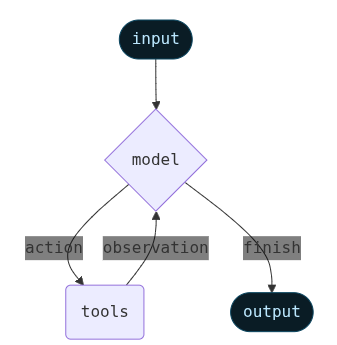

## 5.2 Tools

Tools extend what agents can do—letting them fetch real-time data, execute code, query external databases, and take actions in the world. Under the hood, tools are callable functions with well-defined inputs and outputs that get passed to a chat model. The model decides when to invoke a tool based on the conversation context, and what input arguments to provide.

In [111]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.tools import tool

class WeatherInput(BaseModel):
    """Input for weather queries."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit preference"
    )
    include_forecast: bool = Field(
        default=False,
        description="Include 5-day forecast"
    )

@tool(args_schema=WeatherInput)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result


Now, let's use the tool

In [112]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain.messages import ToolMessage


agent = create_agent(
    model="google_genai:gemini-2.5-flash-lite",
    tools=[get_weather],
)


question = "What's the weather in San Francisco?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What's the weather in San Francisco?
================================== Ai Message ==================================
Tool Calls:
  get_weather (0c81c8ac-8a9e-4118-8fb9-e1a292c02139)
 Call ID: 0c81c8ac-8a9e-4118-8fb9-e1a292c02139
  Args:
    location: San Francisco
================================= Tool Message =================================
Name: get_weather

Current weather in San Francisco: 22 degrees C
================================== Ai Message ==================================

The current weather in San Francisco is 22 degrees C.


# 6. Structured output

In [113]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.tools import tool
from langchain.agents import create_agent

# --- 1. Tool Input Schema (Existing) ---
# --- 2. Tool Definition (Existing) ---
# --- 3. NEW: Final Output Schema ---
# This defines how you want the AGENT to answer you.
class FinalWeatherReport(BaseModel):
    """The structured response to return to the user."""
    city: str = Field(description="The name of the city")
    temperature: float = Field(description="Numeric temperature value")
    summary: str = Field(description="A short natural language summary of the weather")
    is_good_for_hiking: bool = Field(description="Boolean assessment based on the weather")

# --- 4. Agent Creation ---
agent = create_agent(
    model="google_genai:gemini-2.5-flash-lite",
    tools=[get_weather],
    response_format=FinalWeatherReport
)

question = "What's the weather in San Francisco?"

# --- 5. Execution ---
print(f"Question: {question}\n")

last_step = None
for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    last_step = step
    # Print intermediate steps (thought process/tool calls)
    step["messages"][-1].pretty_print()



Question: What's the weather in San Francisco?

================================ Human Message =================================

What's the weather in San Francisco?
================================== Ai Message ==================================
Tool Calls:
  get_weather (2d908823-6e87-4d50-900b-5478a0e4d7ab)
 Call ID: 2d908823-6e87-4d50-900b-5478a0e4d7ab
  Args:
    location: San Francisco
================================= Tool Message =================================
Name: get_weather

Current weather in San Francisco: 22 degrees C
================================= Tool Message =================================
Name: FinalWeatherReport

Returning structured response: city='San Francisco' temperature=22.0 summary='The weather is nice and sunny.' is_good_for_hiking=True


In [114]:
# --- 6. Accessing the Structured Output ---
# The final structured object is stored in the 'structured_response' key of the final state
structured_data = last_step["structured_response"]
print(f"Raw Object: {structured_data}")
print("**********************")
# You can access fields directly like a Python object
print(f"City: {structured_data.city}")
print(f"Summary: {structured_data.summary}")
print(f"Hiking Decision: {structured_data.is_good_for_hiking}")


Raw Object: city='San Francisco' temperature=22.0 summary='The weather is nice and sunny.' is_good_for_hiking=True
**********************
City: San Francisco
Summary: The weather is nice and sunny.
Hiking Decision: True
